In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

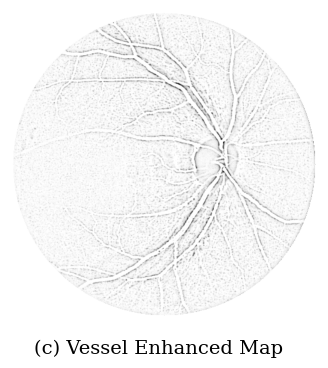

In [2]:
# ==========================================
# Vessel Enhanced Map (Paper Style Output)
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---- Load Image ----
img = cv2.imread("/kaggle/input/datasets/amimulahasanrofik/abu-sayed/Fundus_CIMT_2903 Dataset/100464002_R.png")   # change path
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---- Extract Green Channel ----
green = img[:, :, 1]

# ---- CLAHE Contrast Enhancement ----
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
green = clahe.apply(green)

# ---- Multi-scale Vessel Enhancement ----
scales = [1, 2, 3, 4]
vessel = np.zeros_like(green, dtype=np.float32)

for s in scales:
    blur = cv2.GaussianBlur(green, (0,0), s)
    lap = cv2.Laplacian(blur, cv2.CV_32F, ksize=3)
    response = np.maximum(-lap, 0)
    vessel = np.maximum(vessel, response)

# ---- Normalize ----
vessel = cv2.normalize(vessel, None, 0, 255, cv2.NORM_MINMAX)
vessel = vessel.astype(np.uint8)

# ---- Invert for Paper Style ----
vessel = 255 - vessel

# ---- Create Circular Mask ----
h, w = vessel.shape
mask = np.zeros((h, w), dtype=np.uint8)
center = (w//2, h//2)
radius = min(center[0], center[1]) - 5
cv2.circle(mask, center, radius, 255, -1)

# White background
output = np.ones((h, w), dtype=np.uint8) * 255
output[mask == 255] = vessel[mask == 255]

# ---- Plot Final Figure ----
plt.figure(figsize=(4,4))
plt.imshow(output, cmap='gray')
plt.axis("off")
plt.figtext(0.5, 0.02, "(c) Vessel Enhanced Map",
            ha="center", fontsize=14, family="serif")

# ---- Save ----
plt.savefig("vessel_enhanced_map.png",
            bbox_inches="tight",
            dpi=300,
            facecolor="white")

plt.show()


In [3]:
# ============================================================
# UPGRADE CODE V2 (Optimized Publication-Level)
# Better R2 / Lower MAE
# ============================================================

import os, cv2, math, warnings, random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetV2S

# ============================================================
# CONFIG
# ============================================================
CSV_PATH   = "/kaggle/input/datasets/amimulahasanrofik/abu-csv/data_info.csv"
IMG_DIR    = "/kaggle/input/datasets/amimulahasanrofik/abu-sayed/Fundus_CIMT_2903 Dataset"

IMG_SIZE   = 384
BATCH_SIZE = 8
EPOCHS     = 10
FOLDS      = 5
SEED       = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(CSV_PATH)

# Required:
# image_name, thickness, age, gender, group

# -------- Scale Metadata --------
meta_cols = ["age", "gender", "group"]
meta_scaler = StandardScaler()
df[meta_cols] = meta_scaler.fit_transform(df[meta_cols])

# -------- Scale Target --------
y_scaler = StandardScaler()
df["thickness_scaled"] = y_scaler.fit_transform(df[["thickness"]])

print(df.head())

# ============================================================
# IMAGE PREPROCESS
# ============================================================
def retina_crop(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, th = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c = max(cnts, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(c)
    img = img[y:y+h, x:x+w]
    return img

def vessel_map(img):
    green = img[:,:,1]

    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    green = clahe.apply(green)

    bg = cv2.GaussianBlur(green,(25,25),0)
    green = cv2.subtract(green,bg)

    vessel = np.zeros_like(green, dtype=np.float32)

    for s in [1,2,3,4,5]:
        blur = cv2.GaussianBlur(green,(0,0),s)
        lap  = cv2.Laplacian(blur, cv2.CV_32F)
        resp = np.maximum(-lap,0)
        vessel = np.maximum(vessel, resp)

    vessel = cv2.normalize(vessel,None,0,255,cv2.NORM_MINMAX)
    vessel = vessel.astype(np.uint8)
    vessel = cv2.cvtColor(vessel, cv2.COLOR_GRAY2RGB)

    return vessel

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = retina_crop(img)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    return img

def preprocess(path):
    img = load_image(path)
    ves = vessel_map(img)

    img = img / 255.0
    ves = ves / 255.0

    return img.astype(np.float32), ves.astype(np.float32)

# ============================================================
# AUGMENTATION
# ============================================================
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.08)
])

# ============================================================
# GENERATOR
# ============================================================
class DataGen(tf.keras.utils.Sequence):
    def __init__(self, data, batch=8, train=True):
        self.df = data.reset_index(drop=True)
        self.batch = batch
        self.train = train
        self.idx = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df)/self.batch)

    def on_epoch_end(self):
        np.random.shuffle(self.idx)

    def __getitem__(self, i):
        inds = self.idx[i*self.batch:(i+1)*self.batch]
        part = self.df.iloc[inds]

        X1,X2,M,Y = [],[],[],[]

        for _,r in part.iterrows():
            path = os.path.join(IMG_DIR, r["image_name"])

            img,ves = preprocess(path)

            X1.append(img)
            X2.append(ves)
            M.append(r[meta_cols].values.astype(np.float32))
            Y.append(r["thickness_scaled"])

        X1 = np.array(X1)
        X2 = np.array(X2)

        if self.train:
            X1 = augment(X1, training=True)
            X2 = augment(X2, training=True)

        return {
            "img_input": X1,
            "ves_input": X2,
            "meta_input": np.array(M)
        }, np.array(Y).astype(np.float32)

# ============================================================
# SE BLOCK
# ============================================================
def se_block(x, ratio=8):
    f = x.shape[-1]
    s = layers.GlobalAveragePooling2D()(x)
    s = layers.Dense(f//ratio, activation='relu')(s)
    s = layers.Dense(f, activation='sigmoid')(s)
    s = layers.Reshape((1,1,f))(s)
    return layers.Multiply()([x,s])

# ============================================================
# MODEL
# ============================================================
def build_model():

    # ---------- RAW IMAGE ----------
    inp1 = layers.Input((IMG_SIZE,IMG_SIZE,3), name="img_input")

    base1 = EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_tensor=inp1
    )

    x1 = base1.output
    x1 = se_block(x1)
    x1 = layers.GlobalAveragePooling2D()(x1)

    # ---------- VESSEL ----------
    inp2 = layers.Input((IMG_SIZE,IMG_SIZE,3), name="ves_input")

    x2 = layers.Conv2D(32,3,padding="same",activation="relu")(inp2)
    x2 = layers.MaxPool2D()(x2)

    x2 = layers.Conv2D(64,3,padding="same",activation="relu")(x2)
    x2 = layers.MaxPool2D()(x2)

    x2 = layers.Conv2D(128,3,padding="same",activation="relu")(x2)
    x2 = layers.MaxPool2D()(x2)

    x2 = layers.Conv2D(256,3,padding="same",activation="relu")(x2)
    x2 = layers.GlobalAveragePooling2D()(x2)

    # ---------- META ----------
    inp3 = layers.Input((3,), name="meta_input")

    x3 = layers.Dense(64,activation="relu")(inp3)
    x3 = layers.Dropout(0.2)(x3)

    # ---------- FUSION ----------
    x = layers.Concatenate()([x1,x2,x3])

    x = layers.Dense(512,activation="relu")(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(256,activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(64,activation="relu")(x)

    out = layers.Dense(1, activation="linear")(x)

    model = Model([inp1,inp2,inp3], out)

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(1e-4, weight_decay=1e-5),
        loss=tf.keras.losses.Huber(),
        metrics=["mae"]
    )

    return model

# ============================================================
# TRAIN
# ============================================================
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=SEED)
scores = []

for fold,(tr,va) in enumerate(kf.split(df)):
    print(f"\n========== FOLD {fold+1} ==========")

    train_df = df.iloc[tr]
    val_df   = df.iloc[va]

    train_gen = DataGen(train_df, BATCH_SIZE, train=True)
    val_gen   = DataGen(val_df, BATCH_SIZE, train=False)

    model = build_model()

    cb = [
        EarlyStopping(monitor="val_mae", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=4, verbose=1),
        ModelCheckpoint(f"best_fold_{fold+1}.h5",
                        monitor="val_mae",
                        save_best_only=True,
                        mode="min")
    ]

    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=cb,
        verbose=1
    )

    # ---------- Predict ----------
    pred_scaled = model.predict(val_gen).ravel()
    true_scaled = val_df["thickness_scaled"].values

    pred = y_scaler.inverse_transform(pred_scaled.reshape(-1,1)).ravel()
    true = y_scaler.inverse_transform(true_scaled.reshape(-1,1)).ravel()

    mae  = mean_absolute_error(true,pred)
    rmse = np.sqrt(mean_squared_error(true,pred))
    r2   = r2_score(true,pred)

    print(f"Fold {fold+1} MAE : {mae:.4f}")
    print(f"Fold {fold+1} RMSE: {rmse:.4f}")
    print(f"Fold {fold+1} R2  : {r2:.4f}")

    scores.append([mae,rmse,r2])

# ============================================================
# FINAL SCORE
# ============================================================
scores = np.array(scores)

print("\n======================")
print("FINAL RESULTS")
print("======================")
print("MAE :", scores[:,0].mean())
print("RMSE:", scores[:,1].mean())
print("R2  :", scores[:,2].mean())

# ============================================================
# SAVE
# ============================================================
model.save("RetinaThicknessNet_V2.h5")

# ============================================================
# SINGLE PREDICT
# ============================================================
def predict_one(image_name, age, gender, group):

    meta = np.array([[age, gender, group]], dtype=np.float32)
    meta = meta_scaler.transform(meta)

    path = os.path.join(IMG_DIR, image_name)
    img,ves = preprocess(path)

    pred_scaled = model.predict({
        "img_input": np.expand_dims(img,0),
        "ves_input": np.expand_dims(ves,0),
        "meta_input": meta
    })[0][0]

    pred = y_scaler.inverse_transform([[pred_scaled]])[0][0]
    return pred

# Example:
# p = predict_one("2491006_R.png",0.68,0,1)
# print("Predicted Thickness:", p)


      image_name  thickness  label  True_age       age    gender     group  \
0  2491006_R.png        0.8      0        63  1.165303 -1.337410 -0.318042   
1  2491006_L.png        0.8      0        63  1.165303 -1.337410 -0.318042   
2  3730004_R.png        1.2      1        61  1.010544  0.747714 -0.318042   
3  3730004_L.png        1.2      1        61  1.010544  0.747714 -0.318042   
4  3730006_R.png        1.2      1        64  1.242683  0.747714 -0.318042   

   thickness_scaled  
0         -1.000174  
1         -1.000174  
2          1.134246  
3          1.134246  
4          1.134246  

========== FOLD 1 ==========
Epoch 1/10
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - loss: 0.3550 - mae: 0.7228

581/581 ━━━━━━━━━━━━━━━━━━━━ 541s 600ms/step - loss: 0.3549 - mae: 0.7227 - val_loss: 0.2712 - val_mae: 0.5902 - learning_rate: 1.0000e-04
Epoch 2/10
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - loss: 0.2867 - mae: 0.6151

581/581 ━━━━━━━━━━━━━━━━━━━━ 225s 388ms/step - loss: 0.2867 - mae: 0.6151 - val_loss: 0.2735 - val_mae: 0.5882 - learning_rate: 1.0000e-04
Epoch 3/10
581/581 ━━━━━━━━━━━━━━━━━━━━ 232s 398ms/step - loss: 0.2722 - mae: 0.5935 - val_loss: 0.2980 - val_mae: 0.6162 - learning_rate: 1.0000e-04
Epoch 4/10
581/581 ━━━━━━━━━━━━━━━━━━━━ 230s 396ms/step - loss: 0.2716 - mae: 0.5910 - val_loss: 0.2768 - val_mae: 0.5895 - learning_rate: 1.0000e-04
Epoch 5/10
581/581 ━━━━━━━━━━━━━━━━━━━━ 229s 394ms/step - loss: 0.2681 - mae: 0.5861 - val_loss: 0.2774 - val_mae: 0.5940 - learning_rate: 1.0000e-04
Epoch 6/10
581/581 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 0.2664 - mae: 0.5860
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
581/581 ━━━━━━━━━━━━━━━━━━━━ 217s 373ms/step - loss: 0.2664 - mae: 0.5860 - val_loss: 0.2741 - val_mae: 0.5883 - learning_rate: 1.0000e-04
Epoch 7/10
581/581 ━━━━━━━━━━━━━━━━━━━━ 218s 375ms/step - loss: 0.2561 - mae: 0.5719 - val_loss: 0.2773 - val_mae

KeyboardInterrupt: 

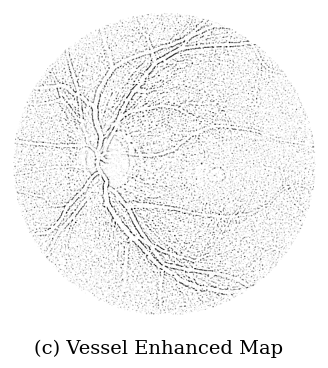

In [1]:
# ==========================================
# Strong Vessel Highlighted Map (Paper Style)
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---- Load Image ----
img = cv2.imread("/kaggle/input/datasets/amimulahasanrofik/abu-sayed/Fundus_CIMT_2903 Dataset/100464002_L.png")   # change path
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---- Green Channel ----
green = img[:, :, 1]

# ---- Strong Contrast Enhancement ----
clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
green = clahe.apply(green)

# ---- Background Removal ----
bg = cv2.GaussianBlur(green, (21,21), 0)
enhanced = cv2.subtract(green, bg)

# ---- Multi-scale Vessel Detection ----
scales = [1,2,3,4,5]
vessel = np.zeros_like(enhanced, dtype=np.float32)

for s in scales:
    blur = cv2.GaussianBlur(enhanced, (0,0), s)
    lap = cv2.Laplacian(blur, cv2.CV_32F, ksize=3)
    response = np.maximum(-lap, 0)
    vessel = np.maximum(vessel, response)

# ---- Normalize ----
vessel = cv2.normalize(vessel, None, 0, 255, cv2.NORM_MINMAX)
vessel = vessel.astype(np.uint8)

# ---- Sharpen Vessel Lines ----
kernel = np.array([[0,-1,0],
                   [-1,5,-1],
                   [0,-1,0]])
vessel = cv2.filter2D(vessel, -1, kernel)

# ---- Threshold Weak Noise ----
_, vessel = cv2.threshold(vessel, 25, 255, cv2.THRESH_TOZERO)

# ---- Invert for White Background ----
vessel = 255 - vessel

# ---- Circular Retina Mask ----
h, w = vessel.shape
mask = np.zeros((h,w), dtype=np.uint8)
center = (w//2, h//2)
radius = min(center[0], center[1]) - 5
cv2.circle(mask, center, radius, 255, -1)

output = np.ones((h,w), dtype=np.uint8) * 255
output[mask==255] = vessel[mask==255]

# ---- Show + Save ----
plt.figure(figsize=(4,4))
plt.imshow(output, cmap='gray')
plt.axis("off")
plt.figtext(0.5, 0.02, "(c) Vessel Enhanced Map",
            ha="center", fontsize=14, family="serif")

plt.savefig("strong_vessel_map.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white")

plt.show()


In [1]:
# # ============================================================
# # PUBLICATION-LEVEL MODEL
# # Retinal Thickness Prediction from Fundus Images
# # Full Kaggle Code (TensorFlow / Keras)
# # ============================================================

# # =========================
# # 1. INSTALL / IMPORT
# # =========================
# import os, cv2, math, random, warnings
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# warnings.filterwarnings("ignore")

# from sklearn.model_selection import KFold
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# import tensorflow as tf
# from tensorflow.keras import layers, Model
# from tensorflow.keras.applications import EfficientNetB3
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# print("TensorFlow:", tf.__version__)

# # =========================
# # 2. CONFIG
# # =========================
# CSV_PATH   = "/kaggle/input/datasets/amimulahasanrofik/abu-csv/data_info.csv"
# IMG_DIR    = "/kaggle/input/datasets/amimulahasanrofik/abu-sayed/Fundus_CIMT_2903 Dataset"

# IMG_SIZE   = 300
# BATCH_SIZE = 16
# EPOCHS     = 10
# FOLDS      = 5
# SEED       = 42

# np.random.seed(SEED)
# tf.random.set_seed(SEED)

# # =========================
# # 3. LOAD CSV
# # =========================
# df = pd.read_csv(CSV_PATH)

# # Required columns:
# # image_name, thickness, age, gender, group

# print(df.head())
# print("Total:", len(df))

# # =========================
# # 4. PREPROCESS FUNCTIONS
# # =========================
# def clahe_green(img):
#     green = img[:,:,1]
#     clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
#     green = clahe.apply(green)
#     return green

# def vessel_map(img):
#     g = clahe_green(img)

#     bg = cv2.GaussianBlur(g, (21,21), 0)
#     g = cv2.subtract(g, bg)

#     vessel = np.zeros_like(g, dtype=np.float32)

#     for s in [1,2,3,4]:
#         blur = cv2.GaussianBlur(g, (0,0), s)
#         lap = cv2.Laplacian(blur, cv2.CV_32F, ksize=3)
#         resp = np.maximum(-lap, 0)
#         vessel = np.maximum(vessel, resp)

#     vessel = cv2.normalize(vessel, None, 0, 255, cv2.NORM_MINMAX)
#     vessel = vessel.astype(np.uint8)

#     vessel = cv2.cvtColor(vessel, cv2.COLOR_GRAY2RGB)
#     return vessel

# def load_image(path):
#     img = cv2.imread(path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
#     return img

# def preprocess(path):
#     img = load_image(path)
#     ves = vessel_map(img)

#     img = img / 255.0
#     ves = ves / 255.0

#     return img.astype(np.float32), ves.astype(np.float32)

# # =========================
# # 5. DATA GENERATOR
# # =========================
# class DataGen(tf.keras.utils.Sequence):
#     def __init__(self, data, batch_size=16, shuffle=True):
#         self.data = data.reset_index(drop=True)
#         self.batch = batch_size
#         self.shuffle = shuffle
#         self.indexes = np.arange(len(self.data))
#         self.on_epoch_end()

#     def __len__(self):
#         return math.ceil(len(self.data)/self.batch)

#     def __getitem__(self, idx):
#         inds = self.indexes[idx*self.batch:(idx+1)*self.batch]
#         batch_df = self.data.iloc[inds]

#         X1, X2, META, Y = [], [], [], []

#         for _, row in batch_df.iterrows():
#             path = os.path.join(IMG_DIR, row["image_name"])

#             img, ves = preprocess(path)

#             meta = np.array([
#                 row["age"],
#                 row["gender"],
#                 row["group"]
#             ], dtype=np.float32)

#             X1.append(img)
#             X2.append(ves)
#             META.append(meta)
#             Y.append(row["thickness"])

#         return (
#             {
#                 "img_input": np.array(X1),
#                 "ves_input": np.array(X2),
#                 "meta_input": np.array(META)
#             },
#             np.array(Y, dtype=np.float32)
#         )

#     def on_epoch_end(self):
#         if self.shuffle:
#             np.random.shuffle(self.indexes)

# # =========================
# # 6. MODEL
# # =========================
# def build_model():

#     # -------- RAW IMAGE BRANCH --------
#     img_input = layers.Input(shape=(IMG_SIZE,IMG_SIZE,3), name="img_input")

#     base1 = EfficientNetB3(
#         include_top=False,
#         weights="imagenet",
#         input_tensor=img_input
#     )

#     x1 = layers.GlobalAveragePooling2D()(base1.output)

#     # -------- VESSEL BRANCH --------
#     ves_input = layers.Input(shape=(IMG_SIZE,IMG_SIZE,3), name="ves_input")

#     x2 = layers.Conv2D(32,3,padding="same",activation="relu")(ves_input)
#     x2 = layers.MaxPool2D()(x2)

#     x2 = layers.Conv2D(64,3,padding="same",activation="relu")(x2)
#     x2 = layers.MaxPool2D()(x2)

#     x2 = layers.Conv2D(128,3,padding="same",activation="relu")(x2)
#     x2 = layers.GlobalAveragePooling2D()(x2)

#     # -------- META BRANCH --------
#     meta_input = layers.Input(shape=(3,), name="meta_input")

#     x3 = layers.Dense(32, activation="relu")(meta_input)
#     x3 = layers.Dropout(0.2)(x3)

#     # -------- FUSION --------
#     x = layers.Concatenate()([x1, x2, x3])

#     x = layers.Dense(256, activation="relu")(x)
#     x = layers.Dropout(0.3)(x)

#     x = layers.Dense(128, activation="relu")(x)
#     x = layers.Dropout(0.2)(x)

#     output = layers.Dense(1, activation="linear")(x)

#     model = Model(
#         inputs=[img_input, ves_input, meta_input],
#         outputs=output
#     )

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(1e-4),
#         loss=tf.keras.losses.Huber(),
#         metrics=["mae"]
#     )

#     return model

# # =========================
# # 7. CROSS VALIDATION
# # =========================
# kf = KFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

# all_scores = []

# for fold, (tr_idx, va_idx) in enumerate(kf.split(df)):
#     print(f"\n========== FOLD {fold+1} ==========")

#     train_df = df.iloc[tr_idx]
#     val_df   = df.iloc[va_idx]

#     train_gen = DataGen(train_df, BATCH_SIZE, shuffle=True)
#     val_gen   = DataGen(val_df, BATCH_SIZE, shuffle=False)

#     model = build_model()

#     ckpt = ModelCheckpoint(
#         f"best_fold_{fold+1}.h5",
#         monitor="val_mae",
#         save_best_only=True,
#         mode="min",
#         verbose=1
#     )

#     es = EarlyStopping(
#         monitor="val_mae",
#         patience=8,
#         restore_best_weights=True,
#         mode="min"
#     )

#     rlrop = ReduceLROnPlateau(
#         monitor="val_mae",
#         factor=0.5,
#         patience=4,
#         verbose=1,
#         mode="min"
#     )

#     history = model.fit(
#         train_gen,
#         validation_data=val_gen,
#         epochs=EPOCHS,
#         callbacks=[ckpt, es, rlrop],
#         verbose=1
#     )

#     # -------- Evaluate --------
#     preds = model.predict(val_gen).ravel()
#     true  = val_df["thickness"].values

#     mae  = mean_absolute_error(true, preds)
#     rmse = np.sqrt(mean_squared_error(true, preds))
#     r2   = r2_score(true, preds)

#     print(f"Fold {fold+1} MAE : {mae:.4f}")
#     print(f"Fold {fold+1} RMSE: {rmse:.4f}")
#     print(f"Fold {fold+1} R2  : {r2:.4f}")

#     all_scores.append([mae, rmse, r2])

# # =========================
# # 8. FINAL RESULT
# # =========================
# scores = np.array(all_scores)

# print("\n==============================")
# print("FINAL 5-FOLD RESULTS")
# print("==============================")
# print("MAE :", scores[:,0].mean())
# print("RMSE:", scores[:,1].mean())
# print("R2  :", scores[:,2].mean())

# # =========================
# # 9. SAVE FINAL MODEL
# # =========================
# model.save("RetinaThicknessNet_Final.h5")
# print("Model Saved!")

# # =========================
# # 10. SINGLE PREDICTION
# # =========================
# def predict_single(image_name, age, gender, group):
#     path = os.path.join(IMG_DIR, image_name)

#     img, ves = preprocess(path)

#     pred = model.predict({
#         "img_input": np.expand_dims(img,0),
#         "ves_input": np.expand_dims(ves,0),
#         "meta_input": np.array([[age, gender, group]], dtype=np.float32)
#     })[0][0]

#     return pred

# # Example:
# # p = predict_single("2491006_R.png",0.68,0,1)
# # print("Predicted Thickness:", p)


2026-04-14 16:16:31.174030: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776183391.418696      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776183391.482196      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776183392.032210      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776183392.032265      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776183392.032268      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
      image_name  thickness  label  True_age       age  gender  group
0  2491006_R.png        0.8      0        63  0.684932       0      1
1  2491006_L.png        0.8      0        63  0.684932       0      1
2  3730004_R.png        1.2      1        61  0.657534       1      1
3  3730004_L.png        1.2      1        61  0.657534       1      1
4  3730006_R.png        1.2      1        64  0.698630       1      1
Total: 5806

========== FOLD 1 ==========


I0000 00:00:1776183419.526057      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


I0000 00:00:1776183491.117176     129 service.cc:152] XLA service 0x7fa0740024e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776183491.117219     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776183503.324727     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-14 16:18:45.851764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-14 16:18:46.044595: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-14 16:18:46.595365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

...

2026-04-14 16:56:32.313132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-14 16:56:32.505449: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-14 16:56:32.980760: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-14 16:56:33.196857: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - loss: 0.0616 - mae: 0.2720
Epoch 1: val_mae improved from inf to 0.16945, saving model to best_fold_2.h5


291/291 ━━━━━━━━━━━━━━━━━━━━ 358s 786ms/step - loss: 0.0616 - mae: 0.2718 - val_loss: 0.0201 - val_mae: 0.1694 - learning_rate: 1.0000e-04
Epoch 2/50
291/291 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - loss: 0.0230 - mae: 0.1703
Epoch 2: val_mae improved from 0.16945 to 0.15822, saving model to best_fold_2.h5


291/291 ━━━━━━━━━━━━━━━━━━━━ 125s 429ms/step - loss: 0.0230 - mae: 0.1703 - val_loss: 0.0190 - val_mae: 0.1582 - learning_rate: 1.0000e-04
Epoch 3/50
 96/291 ━━━━━━━━━━━━━━━━━━━━ 1:08 350ms/step - loss: 0.0219 - mae: 0.1672

KeyboardInterrupt: 